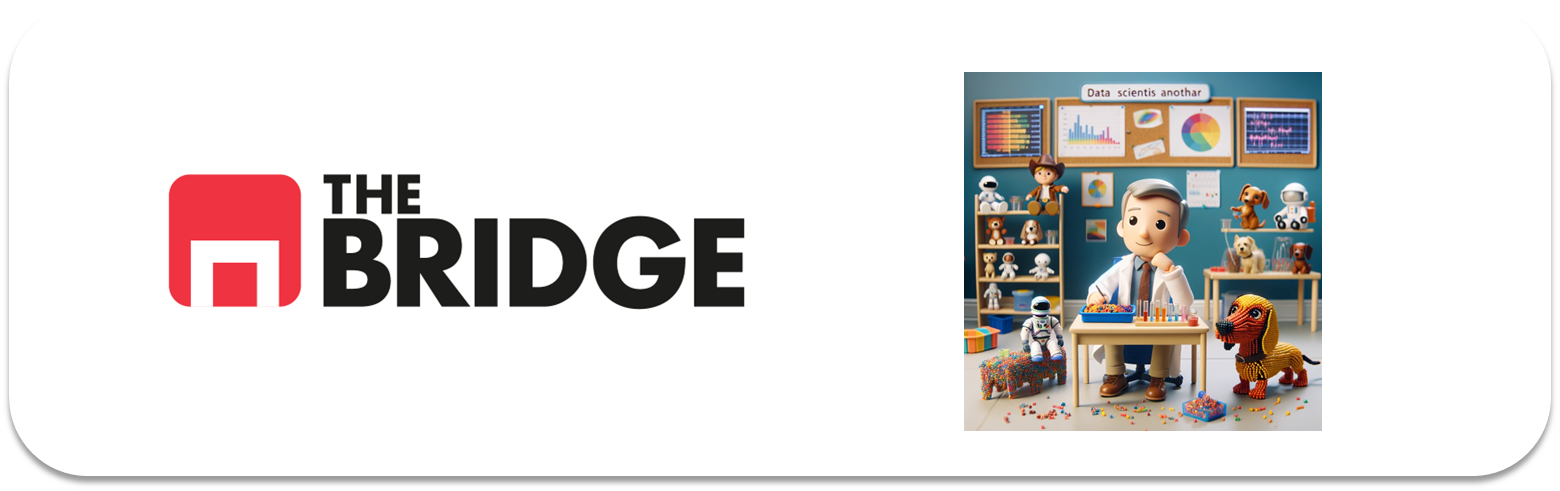

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df_titanic = sns.load_dataset('titanic')
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df_titanic.info()
print(df_titanic["fare"].value_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
<bound method IndexOpsMixin.value_counts of 0       7.2500
1      71.2833
2    

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [6]:
# columnas con nulos
#age, embarked, deck, embark_town
# solumnas sin nulos
columnas_nulos = df_titanic.columns[df_titanic.notna().all()].to_list()
print(df_titanic.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [7]:
# columans con algún nulo
df_titanic.columns[df_titanic.isna().any()].to_list()

['age', 'embarked', 'deck', 'embark_town']

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [8]:
df_titanic.isna().mean() *100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [9]:
df_titanic.drop(columns="parch", inplace=True)

df_titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'fare', 'embarked',
       'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'],
      dtype='object')

### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción | Tipo de variable | Importancia inicial | Notas |
| ---------------- | ----------- |----------------- |---------------- |------ |
| survived     | booleana numérica el pasajero sobrevivió o no | numérica discreta se puede tratar como categórica nominal / booleana | 0 | Esencial para estudio de mortalidad |
| pclass     | clase del pasajero | numérica discreta se puede tratar como categórica nominal | 2 | Podría indicar si alguna clase social tuvo más posiblidades de sobreviivr |
| sex     | género  | categórica nominal | 1 | Demográfica |
| age     | edad |  numérica continua | 1 | Demográfica |
| sibsp     | Es el numero de hermanos / cónyuges que viajan el pasajero | numérica discreta | 3 |  |
| parch     | numero de padres / hijos del pasajero | numérica discreta | 3 |  |
| fare     | Tarifa o precio del pasaje | numérica continua | 2 | estará directamente relacionada con pclass |
| embarked     | Puerto desde donde se embarcó (C=Cherbourg, Q=Queenstown, S=Southampton) | categórica nominal | 3 | |
| class     | Clase | categórica nominal | 2 | estará directamente relacionada con fare y pclass |
| who     | hombre, mujer o niño (man/woman/man) | categórica nominal | 3 | información cubierta por las columnas sex y age  |
| adult_male     | booleano si es hombre adulto | booleano | 3 | información cubierta por las columnas sex y age |
| deck     | Cubierta correspondiente al camarote |  categórica nominal | 3 |  |
| embark_town     | Nombre completo del puerto de embarque |  categórica nominal | 3 |  |
| alive     | categórica Booleano si sobrevivó | booleana o categorica nominal | 4 | es la transcripción en texto de survived, la ignoraremos  |
| alone     | Viajaba solo o no | booleana | 3 |  |



0: survived  
1: sex, age  
2: pclass, fare, class  
3: sibsp, parch, embarked, who, adult_male, deck, embark_town, alone
4: alive

### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [12]:
# C=Cherbourg, Q=Queenstown, S=Southampton
df_titanic['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

### #2.1 Categóricas TENDENCIA CENTRAL

In [ ]:
# TENDENCIA CENTRAL PARA CATEGÓRICAS: MEDIANA EN ORDINALES Y MODA EN NOMINALES
# categorías nominales
# WHO, CLASS, EMBARKED, 
# boolanas (moda y mediana coincidirían, SURVIVED y ALONE) (MODA MEDIANA MEDIA)
# ["SURVIVED","WHO","age","fare","CLASS","EMBARKED","ALONE"]

In [23]:
df_titanic.describe()

,survived,pclass,age,sibsp,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,32.204208
std,0.486592,0.836071,14.526497,1.102743,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,512.329200


In [71]:
# en categóricas sólo hay booleanas y nominales para las nominales, who class embarked sacamos sólo moda 
print("MODA sólo para las categóricas nominales y booleanas:")
categoricas_nominales = ["who", "class", "embarked"]
categoricas_booleanas = "survived"
for col in categoricas_nominales:
    moda = df_titanic[col].mode()[0]
    print(f"Para '{col.capitalize()}': moda = {moda}")
    

moda = df_titanic[categoricas_booleanas].mode()[0]
print(f"Para '{categoricas_booleanas.capitalize()}': moda = {moda}")

MODA sólo para las categóricas nominales y booleanas:
Para 'Who': moda = man
Para 'Class': moda = Third
Para 'Embarked': moda = S
Para 'Survived': moda = 0


In [67]:
print("MEDIANA Y MEDIA para booleanas: sólo considrearemos la de survived, alive es string y es la transcripción en texto de survived: ")

media = round(df_titanic["survived"].mean(),2)
mediana = df_titanic["survived"].describe().T.loc["50%"]
print(F"Columna Survive: MEDIANA: {mediana}, MODA: {media}")
    # print(f"Para '{col}': media = {round(media,2)}")

MEDIANA Y MEDIA para booleanas: sólo considrearemos la de survived, alive es string y es la transcripción en texto de survived: 
Columna Survive: MEDIANA: 0.0, MODA: 0.38


### #2.2 Numéricas. TENDENCIA CENTRAL

In [68]:
# TENDENCIA CENTRAL PARA NUMÉRICAS: MEDIA Y MEDIANA
# categorías numéricas
# AGE, FARE
# ["survived","who","AGE","FARE","class","embarked","alone"]
numericas = ["age", "fare"]
for col in categoricas_booleanas:
    moda = df_titanic[col].mode()[0]
    print(f"Para '{col.capitalize()}': moda = {moda}")

Para 'Survived': moda = 0
Para 'Alive': moda = no


### 5. FRECUENCIAS VARIABLES CATEGÓRICAS [who, pclass, embarked, survived]

##### 5.1 FRECUENCIAS ABSOLUTAS

In [77]:
categoricas = ["who", "class", "embarked", "survived"]
for categ in categoricas:
    print(f"Para {categ}")
    print(df_titanic[categ].value_counts())
    print("\n"*2)

Para who
who
man      537
woman    271
child     83
Name: count, dtype: int64



Para class
class
Third     491
First     216
Second    184
Name: count, dtype: int64



Para embarked
embarked
S    644
C    168
Q     77
Name: count, dtype: int64



Para survived
survived
0    549
1    342
Name: count, dtype: int64





##### 5.2 FRECUENCIAS RELATIVAS Y VISUALIZACIÓN

In [73]:
categoricas = ["who", "class", "embarked", "survived"]
for categ in categoricas:
    print(f"Para {categ}")
    print(df_titanic[categ].value_counts()/len(df_titanic) * 100)
    print("\n"*2)

Para who
who
man      60.269360
woman    30.415264
child     9.315376
Name: count, dtype: float64



Para class
class
Third     55.106622
First     24.242424
Second    20.650954
Name: count, dtype: float64



Para embarked
embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64



Para survived
survived
0    61.616162
1    38.383838
Name: count, dtype: float64





In [78]:
def pinta_distribucion_categoricas(df, columnas_categoricas, relativa=False, mostrar_valores=False):
    num_columnas = len(columnas_categoricas)
    num_filas = (num_columnas // 2) + (num_columnas % 2)

    fig, axes = plt.subplots(num_filas, 2, figsize=(15, 5 * num_filas))
    axes = axes.flatten() 

    for i, col in enumerate(columnas_categoricas):
        ax = axes[i]
        if relativa:
            total = df[col].value_counts().sum()
            serie = df[col].value_counts().apply(lambda x: x / total)
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia Relativa')
        else:
            serie = df[col].value_counts()
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia')

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if mostrar_valores:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    for j in range(i + 1, num_filas * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

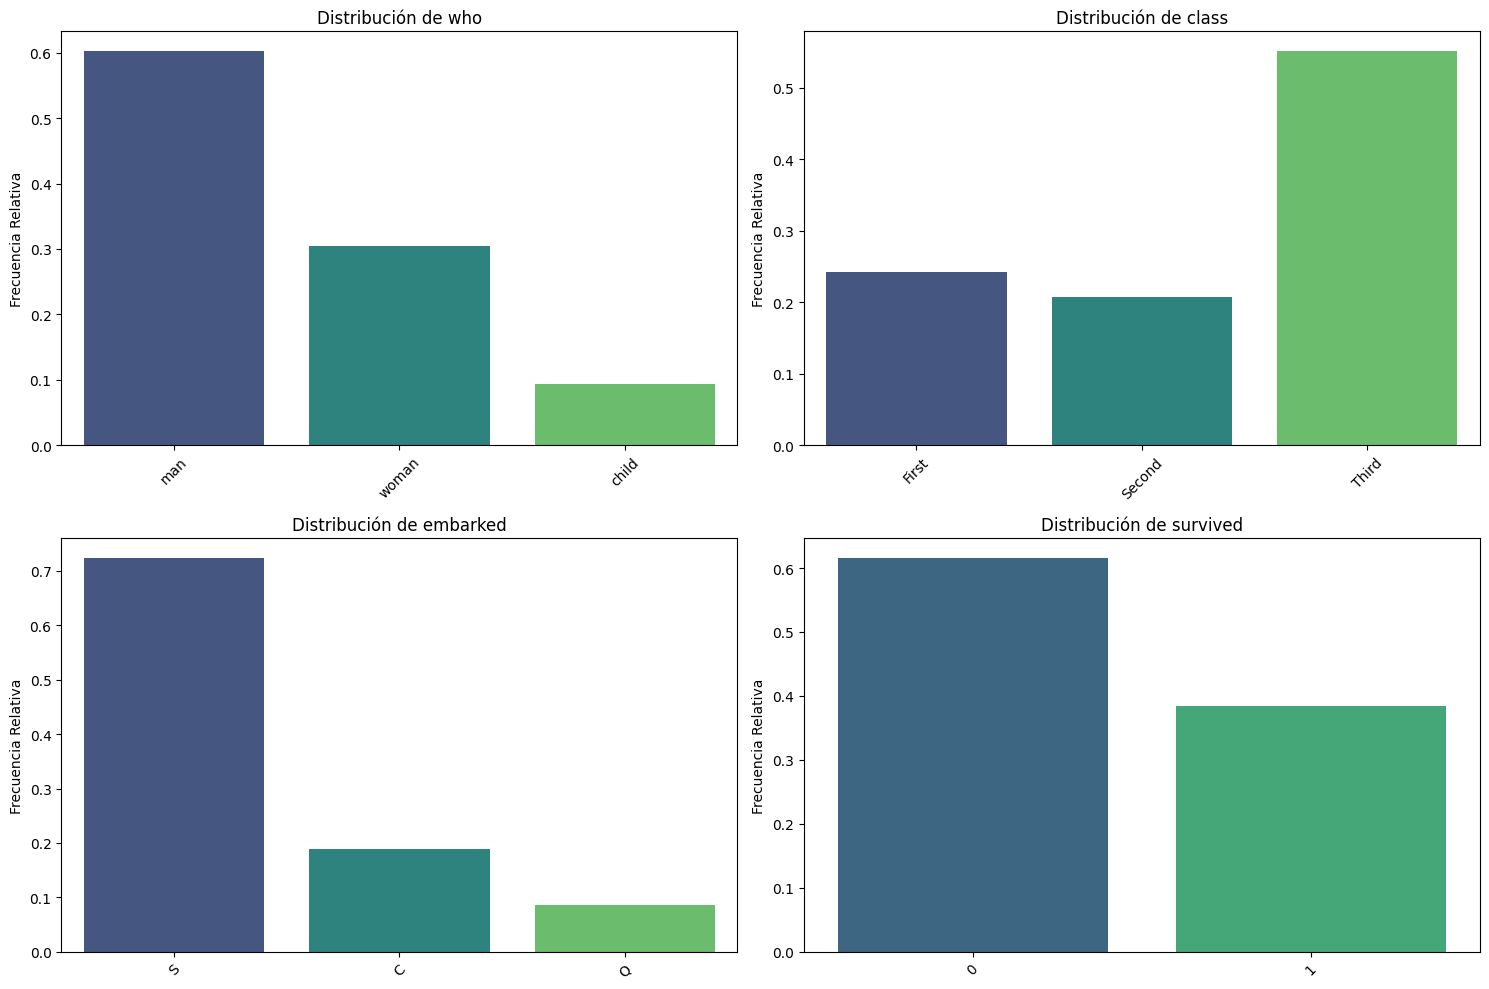

In [79]:
pinta_distribucion_categoricas(df_titanic, categoricas, relativa= True)

#### 6 MEDIDAS DE POSICIÓN Y RANGOS DE VARIABLES NUMÉRICAS

In [80]:
numericas = ["age", "fare"]

##### 6.1 RANGOS

In [83]:
df_titanic.describe().loc["max"] - df_titanic.describe().loc["min"]

survived      1.0000
pclass        2.0000
age          79.5800
sibsp         8.0000
fare        512.3292
dtype: float64

##### 6.2 MEDIDAS DE POSICIÓN. PERCENTILES

In [95]:
print(df_titanic["age"].quantile(0.25),
    df_titanic["age"].quantile(0.5),  # mediana
      df_titanic["age"].quantile(0.75),
     df_titanic["age"].max())

20.125 28.0 38.0 80.0


In [94]:
print(df_titanic["fare"].quantile(0.25), 
    df_titanic["fare"].quantile(0.5), 
      df_titanic["fare"].quantile(0.75),
     df_titanic["fare"].max())

7.9104 14.4542 31.0 512.3292


In [93]:
df_titanic[["age", "fare"]].describe().T[["25%","50%","75%"]]

,25%,50%,75%
age,20.1250,28.0000,38.0
fare,7.9104,14.4542,31.0


In [96]:
def get_IQR(df, col):
    return df[col].quantile(0.75) - df[col].quantile(0.25)

In [97]:
get_IQR(df_titanic, "age")

np.float64(17.875)

In [98]:
get_IQR(df_titanic, "fare")

np.float64(23.0896)

##### 6.3 DIAGRAMAS DE CAJA 

In [81]:
def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

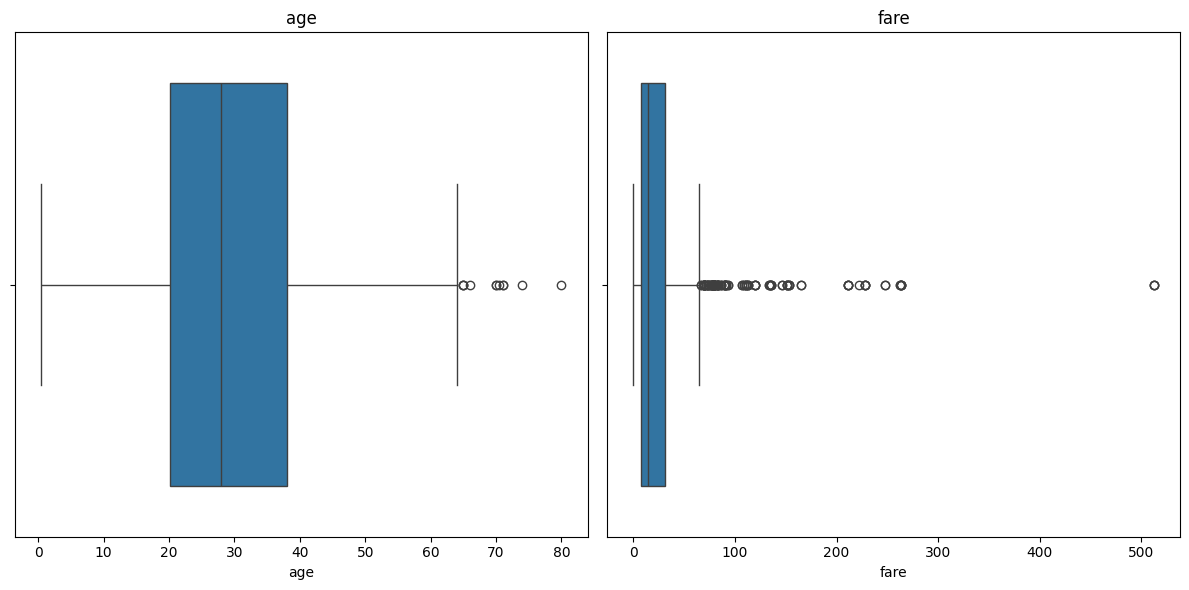

In [82]:
plot_multiple_boxplots(df_titanic, numericas)

#### 7 MEDIDAS DE DISPERSIÓN DE VARIABLES NUMÉRICAS (Varianza y desviación típica)

In [86]:
# vemos la desviación típica respecto a la media, 
df_titanic.describe().loc[["std", "mean"]].T

#para la columna survived la desviación y la media están próximas, y es normal siendo booleana por lo que que sea próxima no aporta mucha información
# PERO la desviación típica máxima en un booleano es 0.5 y aquí es 0.48 por lo tanto la dispersión de los supervivientes es moderada

,std,mean
survived,0.486592,0.383838
pclass,0.836071,2.308642
age,14.526497,29.699118
sibsp,1.102743,0.523008
fare,49.693429,32.204208


In [87]:
def variablidad(df):
    df_var = df.describe().loc[["std", "mean"]].T
    df_var["CV"] = df_var["std"] / df_var["mean"]
    return df_var

In [88]:
variablidad(df_titanic)

,std,mean,CV
survived,0.486592,0.383838,1.267701
pclass,0.836071,2.308642,0.362149
age,14.526497,29.699118,0.489122
sibsp,1.102743,0.523008,2.108464
fare,49.693429,32.204208,1.543073


### 8. DISTRIBUCIONES DE VARIABLES NUMÉRICAS (Histogramas y funciones estimadas de densidad)

In [99]:
numericas = ["age", "fare"]

In [100]:
def plot_histo_den(df, columns):
    num_cols = len(columns)
    num_rows = num_cols // 2 + num_cols % 2
    fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, ax=axes[i])
            axes[i].set_title(f'Histograma y KDE de {column}')

    # Ocultar ejes vacíos
    for j in range(i + 1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

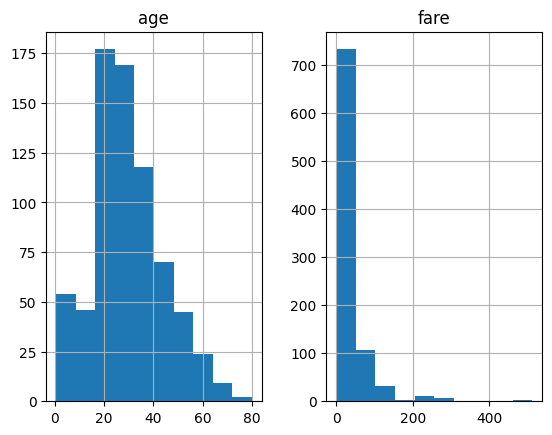

In [101]:
df_titanic[numericas].hist();

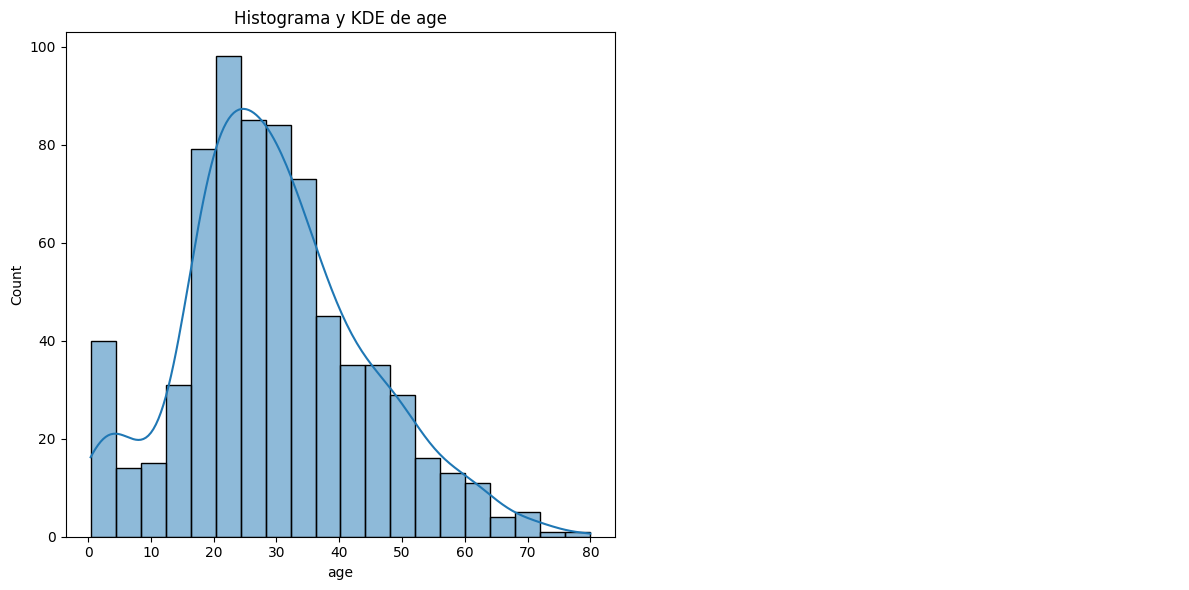

In [105]:
plot_histo_den(df_titanic, ["age"])

In [ ]:
plot_histo_den(df_titanic, ["fare"])

### 9. ANOMALÍAS DETECCIÓN DE OUTLIERS

In [106]:

def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [107]:
def plot_histo_dens(df, columns, bins=None):
    num_cols = len(columns)
    num_rows = num_cols // 2 + num_cols % 2
    fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            if bins:
                sns.histplot(df[column], kde=True, ax=axes[i], bins=bins)
            else:
                sns.histplot(df[column], kde=True, ax=axes[i])
            axes[i].set_title(f'Histograma y KDE de {column}')

    # Ocultar ejes vacíos
    for j in range(i + 1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_combined_graphs(df, columns, whisker_width=1.5):
    num_cols = len(columns)
    if num_cols:
        
        fig, axes = plt.subplots(num_cols, 2, figsize=(12, 5 * num_cols))
        print(axes.shape)

        for i, column in enumerate(columns):
            if df[column].dtype in ['int64', 'float64']:
                # Histograma y KDE
                sns.histplot(df[column], kde=True, ax=axes[i,0] if num_cols > 1 else axes[0])
                if num_cols > 1:
                    axes[i,0].set_title(f'Histograma y KDE de {column}')
                else:
                    axes[0].set_title(f'Histograma y KDE de {column}')

                # Boxplot
                sns.boxplot(x=df[column], ax=axes[i,1] if num_cols > 1 else axes[1], whis=whisker_width)
                if num_cols > 1:
                    axes[i,1].set_title(f'Boxplot de {column}')
                else:
                    axes[1].set_title(f'Boxplot de {column}')

        plt.tight_layout()
        plt.show()

(2,)


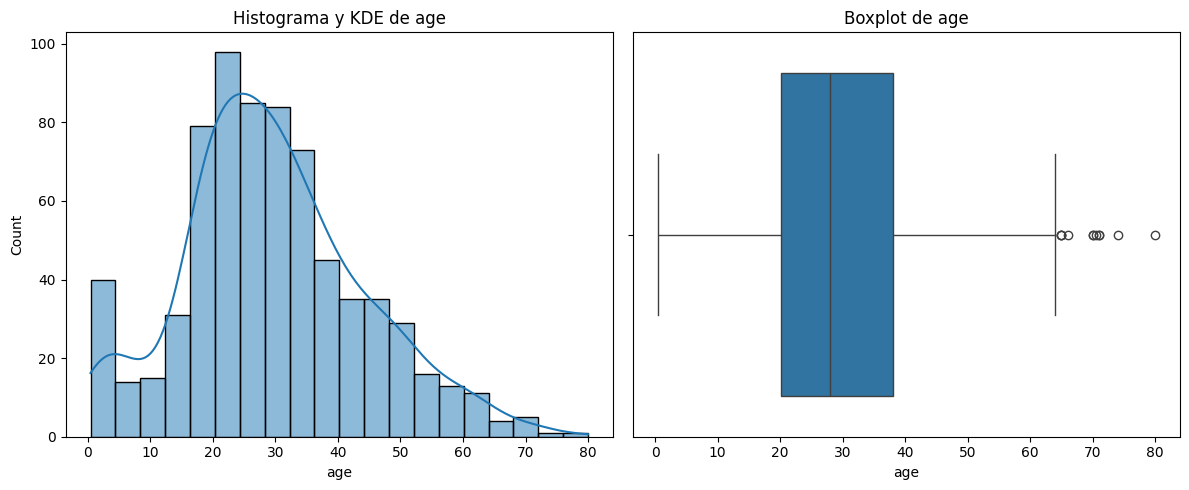

In [109]:
plot_combined_graphs(df_titanic, ["age"])

(2,)


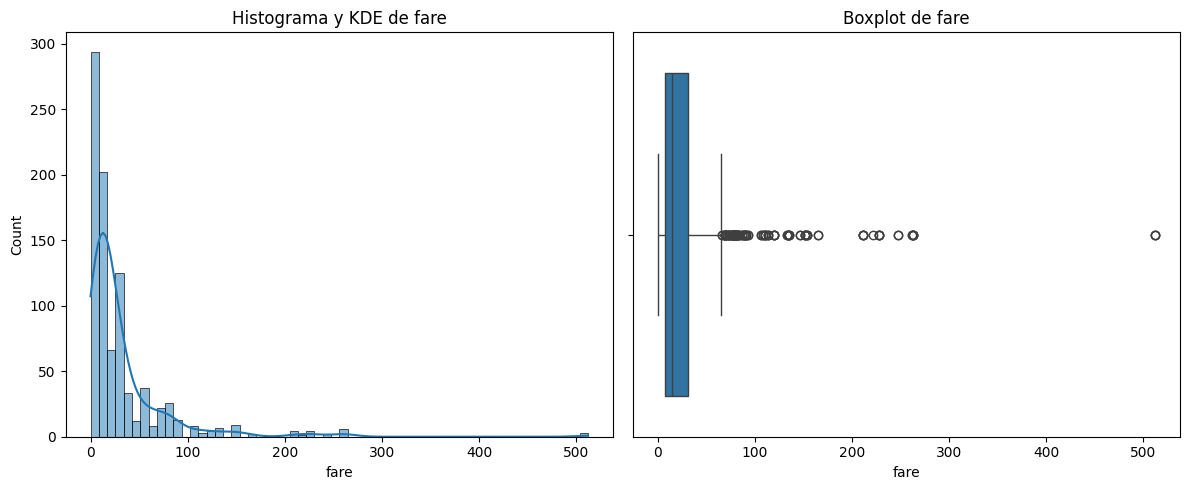

In [110]:
plot_combined_graphs(df_titanic, ["fare"])